In [1]:
from jax import config


config.update("jax_enable_x64", True)

from cmap.clqt_jax import CLQT
from cmap.nonlinear_model_jax import getCLQT_nonlinear 
import matplotlib.pyplot as plt
import jax.numpy as jnp
from cmap.nonlinear_model_data import make_ct_data
from cmap.con_to_dis import y
from cmap.nonlinear_model_jax import intial_guess
from cmap.nonlinear_iclqt import seq_iterate
from cmap.nonlinear_iclqt import par_iterate
from cmap.nonlinear_model_jax import simulate

In [2]:
steps_all=5000

In [3]:
clqt, x0, P0,sigma_v,sigma_omega,r_range,r_bearing = getCLQT_nonlinear(steps_all)

In [4]:
X,y_discrete=make_ct_data(x0, P0(0),steps_all,clqt.T/steps_all,sigma_v,sigma_omega,r_range,r_bearing,seed=123)

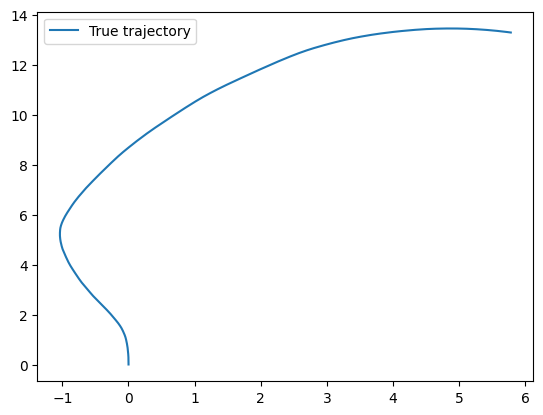

In [5]:
plt.plot(X[:,0],X[:,1],label='True trajectory')
# plt.scatter(y_discrete[:,0],y_discrete[:,1],s=1,label='Measurements')

plt.legend()
plt.show()

In [6]:
_ , u = intial_guess(x0, steps_all)

In [7]:
f = lambda x , t: jnp.array([
        x[2],        # dp_x/dt = vx
        x[3],        # dp_y/dt = vy
        -x[4]*x[3],  # dv_x/dt = -omega * vy
        x[4]*x[2],  # dv_y/dt =  omega * vx
        0.0         # domega/dt = 0
          ], dtype=jnp.float64)

In [8]:
x=simulate(x0,f,steps_all,clqt.T/steps_all)

In [9]:
print(x)

[[1.0000e-03 1.0000e-03 0.0000e+00 3.0000e-01 0.0000e+00]
 [1.0000e-03 4.0000e-03 0.0000e+00 3.0000e-01 0.0000e+00]
 [1.0000e-03 7.0000e-03 0.0000e+00 3.0000e-01 0.0000e+00]
 ...
 [1.0000e-03 1.4998e+01 0.0000e+00 3.0000e-01 0.0000e+00]
 [1.0000e-03 1.5001e+01 0.0000e+00 3.0000e-01 0.0000e+00]
 [1.0000e-03 1.5004e+01 0.0000e+00 3.0000e-01 0.0000e+00]]


In [10]:
print(x.shape)

(5002, 5)


In [11]:
x_seq = x
u_seq = u
x_par = x
u_par = u
print(x.shape)

(5002, 5)


In [12]:
niter=1
steps=10
blocks=steps_all//steps

In [13]:
for i in range(niter):
 print("IT",i)
 u_seq, x_seq = seq_iterate(clqt , steps, blocks, u_seq , x_seq,P0(0))


IT 0
S: [[1.e+40 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+40 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+40 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e+40 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e+08]]
S: [[ 1.00e+40 -2.50e+07 -1.00e+38  0.00e+00  0.00e+00]
 [-2.50e+07  1.00e+40  0.00e+00 -1.00e+38  0.00e+00]
 [-1.00e+38  0.00e+00 -2.50e+73  0.00e+00  3.00e+37]
 [ 0.00e+00 -1.00e+38  0.00e+00 -2.50e+73  0.00e+00]
 [ 0.00e+00  0.00e+00  3.00e+37  0.00e+00 -3.99e+10]]
S: [[-2.5000000e+069 -2.6384083e+007 -6.2500000e+104  2.5000000e+005
   7.5000000e+068]
 [-2.6384083e+007 -2.5000000e+069  2.5000000e+005 -6.2500000e+104
   0.0000000e+000]
 [-6.2500000e+104  2.5000000e+005 -1.5625000e+140  0.0000000e+000
   1.8750000e+104]
 [ 2.5000000e+005 -6.2500000e+104  0.0000000e+000 -1.5625000e+140
   0.0000000e+000]
 [ 7.5000000e+068  0.0000000e+000  1.8750000e+104  0.0000000e+000
  -2.2500000e+068]]
S: [[-9.76562500e+202  7.81250000e+103 -2.44140625e+238  9.76562500e+138
   2.92968750e+202]
 [ 7.81250

In [14]:
for i in range(niter):
 u_par, x_par = par_iterate(clqt , steps, blocks, u_par , x_par,P0(0))

S: [[ 2.70082221e+02 -1.83929742e-02 -7.64444669e+02  4.56929803e-02
  -3.14273568e+02]
 [-1.83929742e-02  2.02211336e+01  5.26938909e-02 -2.04148409e+02
   2.16636440e-02]
 [-7.64444669e+02  5.26938909e-02  3.25791850e+03 -1.88070153e-01
   1.82719753e+03]
 [ 4.56929803e-02 -2.04148409e+02 -1.88070153e-01  4.15150373e+03
  -9.84133423e-02]
 [-3.14273568e+02  2.16636440e-02  1.82719753e+03 -9.84133423e-02
   1.60063275e+03]]
S: [[ 8.73706157e+02 -1.24286488e-01 -1.92740485e+03  2.33502011e-01
  -6.05058551e+02]
 [-1.24286488e-01  3.99283644e+01  2.81222245e-01 -4.16479698e+02
   8.91928505e-02]
 [-1.92740485e+03  2.81222245e-01  6.41101980e+03 -7.48775890e-01
   2.78467308e+03]
 [ 2.33502011e-01 -4.16479698e+02 -7.48775890e-01  6.55054515e+03
  -2.99021349e-01]
 [-6.05058551e+02  8.91928505e-02  2.78467308e+03 -2.99021349e-01
   1.93805430e+03]]
S: [[ 8.79708487e+02 -1.25669021e-01 -1.93779022e+03  2.35681871e-01
  -6.07330304e+02]
 [-1.25669021e-01  4.02645430e+01  2.83946217e-01 -4.1

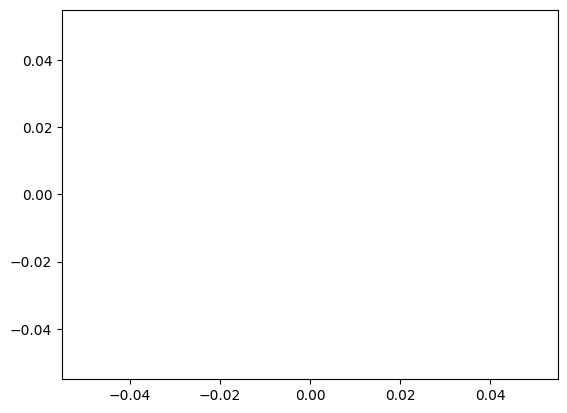

In [15]:
plt.plot(x_seq[:,0],x_seq[:,1],label='Sequential estimate')
# plt.plot(X[:,0],X[:,1],label='True trajectory')

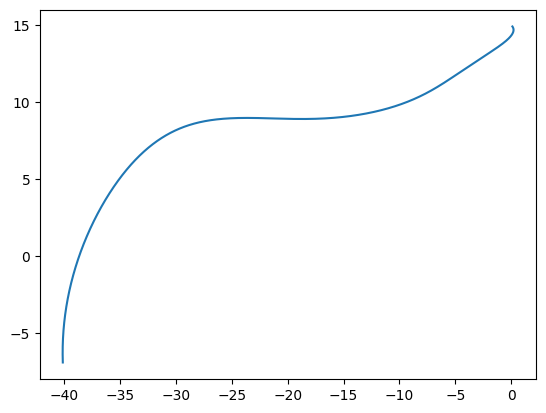

In [16]:
plt.plot(x_par[:,0],x_par[:,1],label='Sequential estimate')
# plt.plot(X[:,0],X[:,1],label='True trajectory')

In [17]:
print(x_seq)

[[nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 ...
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]
